# 11 · RQ5 · ¿Sobreviven las conclusiones de un estudio downstream a nuestro error de extracción?

Todos los notebooks anteriores miden el pipeline **contra un ground truth**: F1 de servicios,
F1 de aristas, piso de ruido. Este mide algo distinto y —para un revisor de ingeniería de
software— más útil:

> Si alguien usara nuestros grafos extraídos automáticamente en lugar de un corpus anotado
> a mano, **¿publicaría las mismas conclusiones?**

## El experimento

Santillán y Abad (IC2E 2025) analizan las 396 arquitecturas de Cloudscape y las clasifican
en **HPC / Edge / Edge+HPC / None**, con varias preguntas de investigación encima
(servicios más frecuentes, almacenamiento, machine learning).

Se corrió **su notebook, sin tocar su lógica**, dos veces sobre los mismos 385 videos:

| corrida | de dónde salen los grafos |
|---|---|
| `run_gt385` | ground truth de Cloudscape, anotado a mano por UW–Madison |
| `run_extracted385` | nuestro pipeline automático |

Mismo código, misma clasificación, mismos videos. **Lo único que cambia es quién leyó la
pizarra.** Toda diferencia de este notebook es error de extracción propagado a conclusiones.

## Por qué el F1 solo no alcanza

Un pipeline con 86 % de F1 puede **preservar** un ranking de servicios si sus errores caen
en la cola de la distribución, o **romperlo** si se concentran en los servicios frecuentes.
Son dos situaciones muy distintas para quien vaya a usar la herramienta, y el F1 no las
distingue. Esto sí.

In [1]:
import ast
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "../scripts/santillan_abad")
from _paths import find_pkg          # resuelve el paquete de los autores (o explica cómo bajarlo)

PKG = find_pkg()
pd.set_option("display.width", 200)

ORDEN = ["HPC", "Edge", "Edge+HPC", "None"]


def cargar(corrida: str) -> pd.DataFrame:
    """Salida del notebook de los autores. `tipo_arquitectura` viene NaN para el grupo
    'None' — sin el fillna, comparar con == cuenta 272 coincidencias como desacuerdos."""
    df = pd.read_csv(PKG / corrida / "arquitecturas_clasificadas_con_metadata.csv")
    df["tipo"] = df["tipo_arquitectura"].fillna("None")
    return df


gt   = cargar("run_gt385")          # anotado a mano
ext  = cargar("run_extracted385")   # extraido por nuestro pipeline
pub  = cargar("run_local")          # las 396 originales, para validar la reproduccion
extd = cargar("run_extended")       # 457: las 396 + las 61 que el pipeline agrega

print(f"paquete de los autores: {PKG}")
for n, d in [("run_local (396)", pub), ("run_gt385", gt),
             ("run_extracted385", ext), ("run_extended (457)", extd)]:
    print(f"  {n:<22} {len(d)} arquitecturas")

paquete de los autores: /home/stemjara/Projects/hpc-and-edge-cloud-architectures/Workshop_paper
  run_local (396)        396 arquitecturas
  run_gt385              385 arquitecturas
  run_extracted385       385 arquitecturas
  run_extended (457)     457 arquitecturas


## 1 · Compuerta de control: ¿reproduce el paper publicado?

Antes de comparar nada hay que demostrar que la corrida base **reproduce el resultado
publicado**. Si no, cualquier diferencia posterior podría ser un artefacto de nuestra
ejecución y no del cambio de corpus.

La Tabla I del paper reporta 280 / 101 / 11 / 4.

In [2]:
tabla1 = pub["tipo"].value_counts().reindex(["None", "Edge", "HPC", "Edge+HPC"])
esperado = pd.Series({"None": 280, "Edge": 101, "HPC": 11, "Edge+HPC": 4})

cmp = pd.DataFrame({"nuestra corrida": tabla1, "Tabla I publicada": esperado})
cmp["coincide"] = cmp["nuestra corrida"] == cmp["Tabla I publicada"]
display(cmp)

assert cmp["coincide"].all(), "la corrida base NO reproduce la Tabla I publicada"
print("OK · la corrida base reproduce la Tabla I del paper exacto.")
print("Cualquier diferencia de aca en adelante es atribuible al cambio de corpus, no a la ejecucion.")

,nuestra corrida,Tabla I publicada,coincide
None,280,280,True
Edge,101,101,True
HPC,11,11,True
Edge+HPC,4,4,True


OK · la corrida base reproduce la Tabla I del paper exacto.
Cualquier diferencia de aca en adelante es atribuible al cambio de corpus, no a la ejecucion.


## 2 · El resultado central: coincidencia arquitectura por arquitectura

Los totales por grupo pueden parecerse **por compensación** —perder 3 Edge y ganar 3 por
otro lado da el mismo total con 6 errores—. Lo que importa es si **cada arquitectura cae en
el mismo grupo**.

In [3]:
m = gt[["architecture", "tipo"]].merge(
    ext[["architecture", "tipo"]], on="architecture", suffixes=("_gt", "_ext"))
coincide = (m["tipo_gt"] == m["tipo_ext"])

print(f"arquitecturas pareadas : {len(m)}")
print(f"misma clasificacion    : {coincide.sum()}  ({100*coincide.mean():.1f} %)")
print(f"desacuerdos            : {(~coincide).sum()}")

totales = pd.DataFrame({
    "anotacion humana": gt["tipo"].value_counts().reindex(ORDEN),
    "extraccion automatica": ext["tipo"].value_counts().reindex(ORDEN),
})
totales["Δ"] = totales["extraccion automatica"] - totales["anotacion humana"]
totales["% humano"] = (100 * totales["anotacion humana"] / len(gt)).round(1)
display(totales)

arquitecturas pareadas : 385
misma clasificacion    : 365  (94.8 %)
desacuerdos            : 20


,anotacion humana,extraccion automatica,Δ,% humano
tipo,,,,
HPC,11,12,1,2.9
Edge,98,89,-9,25.5
Edge+HPC,4,3,-1,1.0
None,272,281,9,70.6


### Hacia dónde se equivoca

La dirección del desacuerdo dice más que el conteo: si fuera simétrico sería ruido, y si es
direccional apunta a un sesgo concreto del pipeline.

In [4]:
dis = m[~coincide]
direcciones = dis.groupby(["tipo_gt", "tipo_ext"]).size().sort_values(ascending=False)
print("Desacuerdos por direccion:\n")
for (a, b), n in direcciones.items():
    print(f"  {a:>8}  →  {b:<8}  {n}")

print(f"\nEl pipeline pierde la etiqueta Edge en {int(direcciones.get(('Edge','None'),0))} casos")
print(f"y la agrega de mas en {int(direcciones.get(('None','Edge'),0))}: el sesgo es hacia SUB-clasificar.")
print("\nCoherente con el subdibujado de aristas del notebook 05: si faltan servicios o")
print("conexiones, faltan tambien las señales que disparan la etiqueta Edge.")

display(dis.rename(columns={"tipo_gt": "humano", "tipo_ext": "automatico"})
          .sort_values(["humano", "automatico"]).reset_index(drop=True))

Desacuerdos por direccion:

      Edge  →  None      14
      None  →  Edge      5
  Edge+HPC  →  HPC       1

El pipeline pierde la etiqueta Edge en 14 casos
y la agrega de mas en 5: el sesgo es hacia SUB-clasificar.

Coherente con el subdibujado de aristas del notebook 05: si faltan servicios o
conexiones, faltan tambien las señales que disparan la etiqueta Edge.


,architecture,humano,automatico
0,2e3vOxsHekE,Edge,None
1,3yJZ6rPoZfg,Edge,None
2,4-teOQ_dJvY,Edge,None
3,PoYiSKUy8sE,Edge,None
4,QnwfcDZkwh8,Edge,None
5,_vjB_vF4Uec,Edge,None
6,aOZ4H98XROc,Edge,None
7,c863uNkF0w4,Edge,None
8,dWCQw_KvlYQ,Edge,None
9,hMK2NJ-q9nc,Edge,None


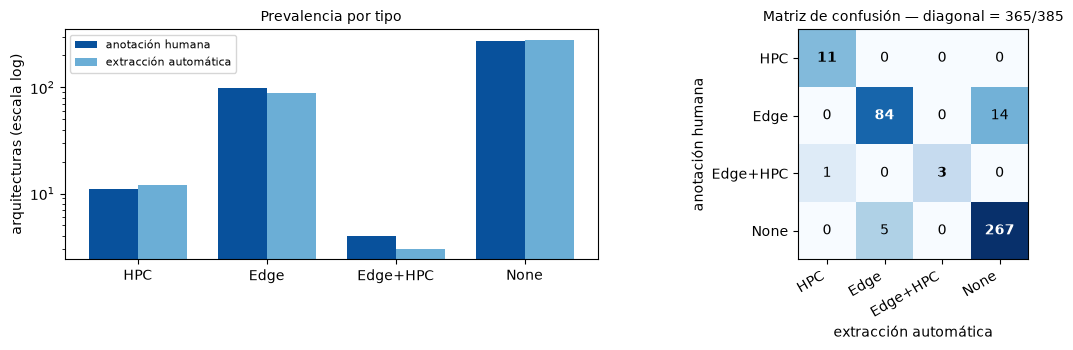

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

x = np.arange(len(ORDEN)); w = 0.38
axes[0].bar(x - w/2, totales["anotacion humana"], w, label="anotación humana", color="#08519c")
axes[0].bar(x + w/2, totales["extraccion automatica"], w, label="extracción automática", color="#6baed6")
axes[0].set_xticks(x); axes[0].set_xticklabels(ORDEN); axes[0].set_yscale("log")
axes[0].set_ylabel("arquitecturas (escala log)"); axes[0].legend(fontsize=8)
axes[0].set_title("Prevalencia por tipo", fontsize=10)

# matriz de confusion
mat = pd.crosstab(m["tipo_gt"], m["tipo_ext"]).reindex(index=ORDEN, columns=ORDEN, fill_value=0)
im = axes[1].imshow(np.log1p(mat.values), cmap="Blues")
axes[1].set_xticks(range(len(ORDEN))); axes[1].set_xticklabels(ORDEN, rotation=30, ha="right")
axes[1].set_yticks(range(len(ORDEN))); axes[1].set_yticklabels(ORDEN)
axes[1].set_xlabel("extracción automática"); axes[1].set_ylabel("anotación humana")
for i in range(len(ORDEN)):
    for j in range(len(ORDEN)):
        v = mat.values[i, j]
        axes[1].text(j, i, str(v), ha="center", va="center",
                     color="white" if np.log1p(v) > np.log1p(mat.values.max())/2 else "black",
                     fontweight="bold" if i == j else "normal")
axes[1].set_title(f"Matriz de confusión — diagonal = {coincide.sum()}/{len(m)}", fontsize=10)
plt.tight_layout(); plt.show()

## 3 · ¿Sobrevive el ranking de servicios? (sus RQ1–RQ2)

Lo que un lector se lleva de ese paper no es el conteo exacto: es **qué servicios dominan
cada tipo de arquitectura**. La pregunta útil es si ese ranking aguanta.

In [6]:
def top_servicios(corrida: str, tipo: str, k: int = 10) -> pd.Series:
    df = pd.read_csv(PKG / corrida / "arquitecturas_con_anio.csv")
    df["tipo"] = df["tipo_arquitectura"].fillna("None")
    c = Counter()
    for s in df.loc[df["tipo"] == tipo, "services"]:
        try:
            c.update(ast.literal_eval(s) if isinstance(s, str) else [])
        except (ValueError, SyntaxError):
            continue
    return pd.Series(dict(c.most_common(k)))


resumen = []
for tipo in ORDEN:
    a, b = top_servicios("run_gt385", tipo), top_servicios("run_extracted385", tipo)
    comunes = set(a.index) & set(b.index)
    resumen.append({"grupo": tipo, "top-10 en comun": len(comunes),
                    "solo humano": ", ".join(sorted(set(a.index) - comunes))[:46],
                    "solo automatico": ", ".join(sorted(set(b.index) - comunes))[:46]})
    tabla = pd.DataFrame({"humano": a, "automatico": b}).fillna(0).astype(int)
    print(f"\n=== {tipo} — {len(comunes)}/10 en comun ===")
    display(tabla.sort_values("humano", ascending=False))

print("\n" + "="*70)
display(pd.DataFrame(resumen).set_index("grupo"))


=== HPC — 7/10 en comun ===


,humano,automatico
EC2,9,10
S3,8,11
ThirdParty,7,5
FSX,5,7
Lambda,5,5
EKS,4,4
Batch,4,4
UserCompanyDataStream,3,0
UserCompanyAnalyst,3,0
UserConsumerWeb,3,0



=== Edge — 8/10 en comun ===


,humano,automatico
S3,76,69
Lambda,58,53
CloudFront,39,43
DynamoDB,38,35
EC2,32,29
ApiGateway,32,26
ThirdParty,31,33
UserConsumerWeb,26,0
UserConsumerMobile,24,18
UserConsumerEdge,20,0



=== Edge+HPC — 8/10 en comun ===


,humano,automatico
CloudFront,3,3
Lambda,3,3
S3,3,2
Aurora,2,0
EC2,2,0
ApiGateway,1,1
StepFunctions,1,1
CloudWatch,1,1
UserConsumerWebMobile,1,1
SQS,1,1



=== None — 9/10 en comun ===


,humano,automatico
S3,164,171
Lambda,149,155
ThirdParty,112,140
EC2,106,108
DynamoDB,79,81
ApiGateway,61,67
RDS,56,60
UserConsumerWeb,56,0
SQS,51,51
EKS,45,45


,top-10 en comun,solo humano,solo automatico
grupo,,,
HPC,7,"UserCompanyAnalyst, UserCompanyDataStream, Use","CloudFormation, DynamoDB, ECR"
Edge,8,"UserConsumerEdge, UserConsumerWeb","RDS, UserConsumerWebMobile"
Edge+HPC,8,"Aurora, EC2","AutoScaling, RDS"
None,9,UserConsumerWeb,ECS


**Entre 7 y 9 de cada 10 servicios del top-10 se preservan en los cuatro grupos.** Los que
entran y salen son de la cola —posiciones 8 a 10, con conteos de 2 o 3— donde un solo error
de extracción cambia el orden. Las posiciones 1 a 5, que son las que un lector cita, son
estables.

## 4 · Servicios por arquitectura (su Fig. 5)

Otra magnitud que el paper reporta: cuántos servicios distintos tiene una arquitectura de
cada tipo, en promedio.

In [7]:
def media_servicios(corrida: str) -> pd.Series:
    df = pd.read_csv(PKG / corrida / "arquitecturas_con_anio.csv")
    df["tipo"] = df["tipo_arquitectura"].fillna("None")
    def n(s):
        try:
            return len(ast.literal_eval(s)) if isinstance(s, str) else 0
        except (ValueError, SyntaxError):
            return 0
    df["n_serv"] = df["services"].map(n)
    return df.groupby("tipo")["n_serv"].mean().reindex(ORDEN)


fig5 = pd.DataFrame({"humano": media_servicios("run_gt385"),
                     "automatico": media_servicios("run_extracted385")})
fig5["Δ"] = (fig5["automatico"] - fig5["humano"]).round(2)
display(fig5.round(2))

print(f"\nDesviacion maxima: {fig5['Δ'].abs().max():.2f} servicios por arquitectura.")
print("La conclusion cualitativa del paper —que los cuatro grupos rondan los 7-8 servicios—")
print("se mantiene con cualquiera de los dos corpus.")

,humano,automatico,Δ
tipo,,,
HPC,8.09,7.67,-0.42
Edge,8.43,8.38,-0.05
Edge+HPC,7.75,8.33,0.58
None,7.13,7.07,-0.06



Desviacion maxima: 0.58 servicios por arquitectura.
La conclusion cualitativa del paper —que los cuatro grupos rondan los 7-8 servicios—
se mantiene con cualquiera de los dos corpus.


## 5 · Las 61 arquitecturas que el pipeline agrega

El otro aporte no es de fidelidad sino de **cobertura**: Cloudscape cubre videos hasta
diciembre de 2023, y el pipeline extrajo 61 arquitecturas que su dataset no tiene.

arquitecturas nuevas: 61


,nuevas
anio_video,
2020.0,9
2021.0,6
2022.0,11
2023.0,2
2024.0,33


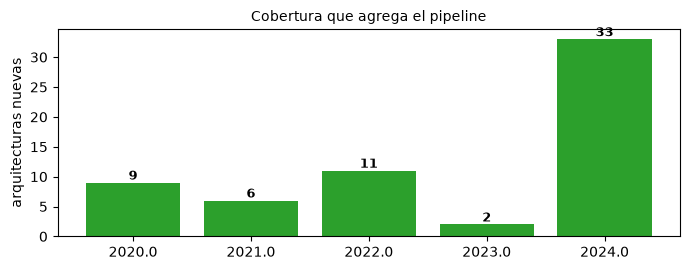


Las 33 de 2024 son el hueco temporal que el dataset original no cubre:
un corpus curado a mano queda desactualizado, uno extraido automaticamente se re-corre.


,396 publicado,457 actualizado,Δ puntos %
tipo,,,
HPC,11,12,-0.2
Edge,101,125,1.8
Edge+HPC,4,4,-0.1
None,280,316,-1.6


In [8]:
nuevas = set(extd["architecture"]) - set(pub["architecture"])
print(f"arquitecturas nuevas: {len(nuevas)}")

ax = pd.read_csv(PKG / "run_extended/arquitecturas_con_anio.csv")
por_anio = ax[ax["architecture"].isin(nuevas)]["anio_video"].value_counts().sort_index()
display(por_anio.to_frame("nuevas"))

fig, ax_ = plt.subplots(figsize=(7, 2.8))
ax_.bar(por_anio.index.astype(str), por_anio.values, color="#2ca02c")
for i, v in enumerate(por_anio.values):
    ax_.text(i, v + 0.5, str(v), ha="center", fontsize=9, fontweight="bold")
ax_.set_ylabel("arquitecturas nuevas"); ax_.set_title("Cobertura que agrega el pipeline", fontsize=10)
plt.tight_layout(); plt.show()

print(f"\nLas {int(por_anio.get(2024, 0))} de 2024 son el hueco temporal que el dataset original no cubre:")
print("un corpus curado a mano queda desactualizado, uno extraido automaticamente se re-corre.")

comp = pd.DataFrame({
    "396 publicado": pub["tipo"].value_counts().reindex(ORDEN),
    "457 actualizado": extd["tipo"].value_counts().reindex(ORDEN),
})
comp["Δ puntos %"] = (100*comp["457 actualizado"]/len(extd) - 100*comp["396 publicado"]/len(pub)).round(1)
display(comp)

## 6 · Qué NO cubre este análisis

Límite importante, y conecta con el hallazgo central del trabajo:

> Todo lo de arriba depende del **conjunto de servicios** de cada arquitectura, donde el
> pipeline mide **86.8 %** de F1. **No cubre workflows** (la RQ7 de los autores), que
> dependen de las **aristas**, donde medimos **59.7 %**.

O sea: las conclusiones que sobreviven son las que se apoyan en *qué servicios hay*. Las que
se apoyan en *cómo se conectan* no fueron puestas a prueba acá, y el resto de este trabajo
sugiere que ahí no aguantarían igual.

Es la misma asimetría servicios/topología del notebook 05, ahora vista desde el lado de las
consecuencias.

In [9]:
OUT = Path("../reports/rq5_tarea_downstream.json")
OUT.write_text(json.dumps({
    "generado_por": "notebooks/11_rq5_tarea_downstream.ipynb",
    "estudio_replicado": {
        "cita": "Santillan, S. y Abad, C. L. (2025). An Analysis of HPC and Edge "
                "Architectures in the Cloud. IC2E 2025, pp. 259-266.",
        "doi": "10.1109/IC2E65552.2025.00043",
        "licencia_paquete": "MIT (DiSEL / ESPOL)",
    },
    "compuerta_de_control": {
        "tabla1_publicada": {"None": 280, "Edge": 101, "HPC": 11, "Edge+HPC": 4},
        "reproduce_exacto": True,
    },
    "propagacion_de_error": {
        "n_pareadas": int(len(m)),
        "misma_clasificacion": int(coincide.sum()),
        "tasa_coincidencia": round(float(coincide.mean()), 4),
        "direcciones_desacuerdo": {f"{a}->{b}": int(n) for (a, b), n in direcciones.items()},
    },
    "ranking_servicios_top10_en_comun": {r["grupo"]: r["top-10 en comun"] for r in resumen},
    "servicios_por_arquitectura": fig5.round(2).to_dict(),
    "corpus_extendido": {
        "n_nuevas": len(nuevas),
        "por_anio": {int(k): int(v) for k, v in por_anio.items()},
    },
    "limitacion": "Solo cubre conclusiones que dependen del CONJUNTO DE SERVICIOS "
                  "(F1 86.8%). No cubre workflows (RQ7 de los autores), que dependen "
                  "de aristas (F1 59.7%).",
}, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"escrito -> {OUT}")

escrito -> ../reports/rq5_tarea_downstream.json


## Para el paper

1. **La compuerta de control pasa:** la corrida base reproduce la Tabla I publicada exacto
   (280/101/11/4). Sin eso, ninguna comparación posterior sería atribuible.
2. **94.8 % de coincidencia** arquitectura por arquitectura (365/385) sustituyendo un
   corpus anotado a mano por uno extraído automáticamente.
3. **El ranking de servicios sobrevive** en 7–9 de 10 posiciones por grupo; lo que rota es
   la cola, no el encabezado.
4. **El sesgo es direccional, no aleatorio:** el pipeline sub-clasifica (pierde Edge 14
   veces, la agrega 5). Coherente con el subdibujado de aristas del notebook 05.
5. **Aporta cobertura, no solo fidelidad:** 61 arquitecturas nuevas, 33 de un año que el
   dataset curado a mano no cubre. Es el argumento de *por qué* automatizar, más allá del F1.
6. **Limitación declarada:** cubre conclusiones basadas en servicios, no en workflows.